<a href="https://colab.research.google.com/github/Ritikkumar09/ML-projects/blob/main/using_decision_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this project:

We used Supervised Machine Learning

Problem Type → Regression

Algorithm → Random Forest

Library → TensorFlow Decision Forests (TFDF)


Random forest is collection of decision tree
its a bagging technique


In [1]:
import tensorflow as tf
import tensorflow_decision_forests as tfdf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


%matplotlib inline

In [2]:
print(tfdf.__version__)

1.12.0


In [3]:
train_file_path = "/content/train.csv"

In [4]:
dataset_df= pd.read_csv(train_file_path)

In [5]:
print(f"Full train dataset shape is {dataset_df.shape}")

Full train dataset shape is (1460, 81)


In [6]:
dataset_df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [7]:
dataset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

we need to drop unnecessory column which will not be useful for our model


In [8]:
dataset_df = dataset_df.drop("Id", axis=1)

In [9]:
dataset_df.head(3)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


we can inspect the type of feature columns using .info() method

In [10]:
dataset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

undestand the Target Variable

In [11]:
print(dataset_df["SalePrice"].describe())

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


Visualize Price Distribution

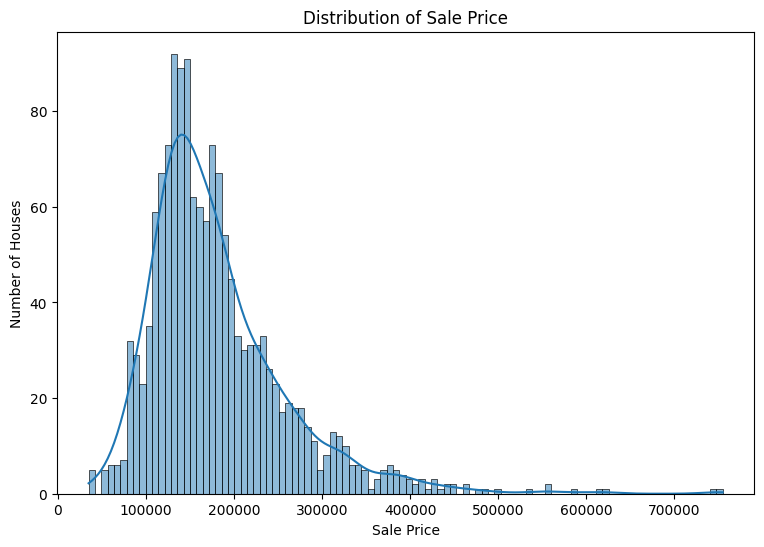

In [12]:
plt.figure(figsize=(9,6))
sns.histplot(dataset_df['SalePrice'], bins=100, kde=True)
plt.title("Distribution of Sale Price")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.show()

Tree models can work with text categories.
Linear and neural models cannot.
so dosn't need convert object data

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
train_df, valid_df = train_test_split( dataset_df, test_size = 0.2, random_state = 42)

In [15]:
print("training dataset shape:", train_df.shape)
print("validation dataset shape:", valid_df.shape)

training dataset shape: (1168, 80)
validation dataset shape: (292, 80)


TFDF is not sklearn.

sklearn → needs X and y

TFDF → prefers full DataFrame + label name
TFDF needs the full table, You just tell it which column is the target. It separates inputs & output internally

In [16]:
#TFDF requires TFDS(tensorflow dataset) formate
Target = "SalePrice"

train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(train_df, label=Target, task=tfdf.keras.Task.REGRESSION)

In [17]:
valid_ds = tfdf.keras.pd_dataframe_to_tf_dataset(valid_df, label=Target, task=tfdf.keras.Task.REGRESSION)

Create random forest regression model

In [18]:
rf_model = tfdf.keras.RandomForestModel(
    task=tfdf.keras.Task.REGRESSION,
    num_trees=300,
    max_depth=16,
    random_seed=42
)

Use /tmp/tmpwjurzarj as temporary training directory


compile model

In [19]:
rf_model.compile(metrics=['mse'])

In [20]:
rf_model.fit(train_ds)

Reading training dataset...
Training dataset read in 0:00:12.309717. Found 1168 examples.
Training model...
Model trained in 0:00:08.102586
Compiling model...
Model compiled.


validation performance

In [21]:
evaluation = rf_model.evaluate(valid_ds, return_dict=True)

1/1 [==============================] - 1s 650ms/step - loss: 0.0000e+00 - mse: 801001536.0000


In [22]:
for metric,value in evaluation.items():
  print(f"{metric}:{value}")

loss:0.0
mse:801001536.0


In [23]:
rf_model.summary()

Model: "random_forest_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________
Type: "RANDOM_FOREST"
Task: REGRESSION
Label: "__LABEL"

Input Features (79):
	1stFlrSF
	2ndFlrSF
	3SsnPorch
	Alley
	BedroomAbvGr
	BldgType
	BsmtCond
	BsmtExposure
	BsmtFinSF1
	BsmtFinSF2
	BsmtFinType1
	BsmtFinType2
	BsmtFullBath
	BsmtHalfBath
	BsmtQual
	BsmtUnfSF
	CentralAir
	Condition1
	Condition2
	Electrical
	EnclosedPorch
	ExterCond
	ExterQual
	Exterior1st
	Exterior2nd
	Fence
	FireplaceQu
	Fireplaces
	Foundation
	FullBath
	Functional
	GarageArea
	GarageCars
	GarageCond
	GarageFinish
	GarageQual
	GarageType
	GarageYrBlt
	GrLivArea
	HalfBath
	Heating
	HeatingQC
	HouseStyle
	KitchenAbvGr
	KitchenQual
	LandContour
	LandSlope
	LotArea
	LotConfig
	LotFrontage
	LotShape
	

In [24]:
predictions = rf_model.predict(valid_ds)


predictions[:5]


1/1 [==============================] - 0s 194ms/step


array([[137859.08],
       [323676.88],
       [112968.26],
       [149065.88],
       [308776.34]], dtype=float32)

In [25]:
test_df = pd.read_csv("/content/test.csv")

In [28]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [29]:
ids= test_df['Id']

In [30]:
test_df = test_df.drop("Id", axis=1)

In [31]:
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    test_df,
    task=tfdf.keras.Task.REGRESSION)

In [32]:
preds= rf_model.predict(test_ds)

2/2 [==============================] - 1s 34ms/step


In [33]:
preds = preds.squeeze()

In [50]:
test_with_pred = test_df.copy()
test_with_pred["Predicted_SalePrice"]=preds
test_with_pred["Id"]=ids

In [57]:
test_with_pred[test_with_pred["Id"]==1461]

,Id,Predicted_SalePrice,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,124976.226562,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal


In [51]:
cols = ["Id", "Predicted_SalePrice"] + \
       [col for col in test_with_pred.columns
        if col not in ["Id", "Predicted_SalePrice"]]

test_with_pred = test_with_pred[cols]


In [52]:
top10 = test_with_pred.sort_values(
    by="Predicted_SalePrice",
    ascending=False
).head(10)

top10


,Id,Predicted_SalePrice,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
1222,2683,483863.28125,60,RL,114.0,17242,Pave,NaN,IR1,Lvl,...,210,0,NaN,NaN,NaN,0,5,2006,WD,Normal
200,1661,447747.65625,60,RL,110.0,14257,Pave,NaN,Reg,Lvl,...,0,0,NaN,NaN,NaN,0,6,2009,WD,Normal
19,1480,442292.25000,20,RL,110.0,14300,Pave,NaN,Reg,HLS,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
1168,2629,438810.81250,60,RL,60.0,18062,Pave,NaN,IR1,HLS,...,0,0,NaN,NaN,NaN,0,9,2006,New,Partial
203,1664,437985.40625,20,RL,105.0,13693,Pave,NaN,Reg,Lvl,...,0,0,NaN,NaN,NaN,0,3,2009,WD,Normal
211,1672,435359.31250,20,RL,110.0,15274,Pave,NaN,IR1,Lvl,...,0,0,NaN,MnPrv,NaN,0,7,2009,WD,Normal
832,2293,434509.56250,20,RL,107.0,13891,Pave,NaN,Reg,Lvl,...,0,0,NaN,NaN,NaN,0,10,2007,New,Partial
1170,2631,434479.96875,60,RL,82.0,16052,Pave,NaN,IR1,Lvl,...,0,0,NaN,NaN,NaN,0,7,2006,New,Partial
514,1975,433993.43750,20,RL,106.0,12720,Pave,NaN,Reg,HLS,...,216,144,Ex,NaN,NaN,0,2,2008,WD,Normal
803,2264,426429.06250,20,RL,52.0,51974,Pave,NaN,IR1,Lvl,...,322,0,NaN,NaN,NaN,0,6,2007,New,Partial


In [34]:
output = pd.DataFrame({
    "Id":ids,
    "SalePrice":preds
})
output.head()

,Id,SalePrice
0,1461,124976.226562
1,1462,155055.828125
2,1463,182562.218750
3,1464,188315.906250
4,1465,201954.328125


In [35]:
output.to_csv("submission.csv", index=False)

HOW MSE RESULT

In [44]:
evaluation = rf_model.evaluate(valid_ds, return_dict=True)

for name, value in evaluation.items():
    print(f"{name}: {value}")


1/1 [==============================] - 0s 340ms/step - loss: 0.0000e+00 - mse: 801001536.0000
loss: 0.0
mse: 801001536.0


RMSE from OOB(out of bag) evaluation

In [45]:
inspector = rf_model.make_inspector()
print(inspector.evaluation())


Evaluation(num_examples=1168, accuracy=None, loss=None, rmse=28784.000674331084, ndcg=None, aucs=None, auuc=None, qini=None)


In [47]:
importances = inspector.variable_importances()["NUM_AS_ROOT"]


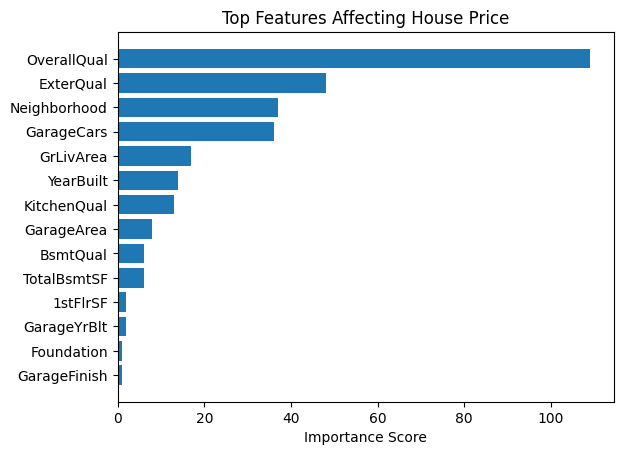

In [49]:
import matplotlib.pyplot as plt

features = [f[0].name for f in importances[:20]]
scores = [f[1] for f in importances[:20]]

plt.barh(features, scores)
plt.xlabel("Importance Score")
plt.title("Top Features Affecting House Price")
plt.gca().invert_yaxis()
plt.show()


The most important feature is Overall Quality, followed by Neighborhood and Living Area, based on Random Forest feature importance analysis.

In this project, a Random Forest regression model was successfully developed using TensorFlow Decision Forests to predict house prices. The model handled categorical and missing values effectively without extensive preprocessing. The model achieved good performance with an RMSE value of approximately 28,784. This project helped in understanding real-world machine learning workflows and laid a strong foundation for advanced regression model comparison in future work.
**bold text**